In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

Overhead_exp1

In [26]:
df1 = pd.read_csv('overhead_exp1.csv')
df2 = pd.read_csv('overhead_exp2.csv')
df3 = pd.read_csv('overhead_exp3.csv')
overhead_exp1 = pd.DataFrame(df1)
overhead_exp1 = overhead_exp1.drop([0,1,2,3])
overhead_exp2 = pd.DataFrame(df2)
overhead_exp2 = overhead_exp2.drop([10, 16])
overhead_exp3 = pd.DataFrame(df3)
overhead_exp2

,filename,total_frames,total_bytes,coap_frames,coap_bytes,mle_frames,mle_bytes,overhead_frames,overhead_pct
0,Task1_PDR_45.pcapng,9340,676794,2402,221952,97,9532,6938,74.28
1,Task1_PDR_46.pcapng,9310,681318,1776,155972,37,3620,7534,80.92
2,Task1_PDR_47.pcapng,9402,690596,2595,241719,46,4495,6807,72.40
3,Task1_PDR_48.pcapng,9575,701054,1627,141649,117,11391,7948,83.01
4,Task1_PDR_49.pcapng,9074,657025,2072,187792,33,3195,7002,77.17
5,Task1_PDR_50.pcapng,8730,623321,2635,247992,36,3536,6095,69.82
6,Task1_PDR_51.pcapng,9061,654772,1747,153612,33,3208,7314,80.72
7,Task1_PDR_52.pcapng,8798,630009,2220,203689,34,3299,6578,74.77
8,Task1_PDR_53.pcapng,8914,639400,2778,262733,42,4110,6136,68.84
9,Task1_PDR_54.pcapng,9083,656863,2063,186900,31,3014,7020,77.29


<Axes: >

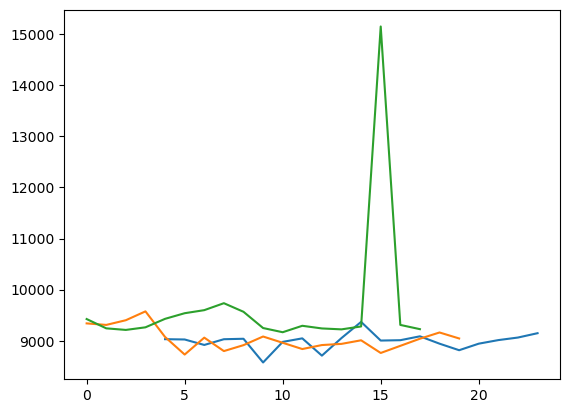

In [23]:
overhead_exp1['total_frames'].plot()
overhead_exp2['total_frames'].plot()
overhead_exp3['total_frames'].plot()

In [27]:
#[overhead_exp1, overhead_exp2, overhead_exp3]
    
confidence_levels = [0.90, 0.95, 0.99]
experiments = {'Experiment 1': overhead_exp1, 'Experiment 2': overhead_exp2, 'Experiment 3': overhead_exp3}

for exp_name, df in experiments.items():
    data = df['overhead_pct'].dropna()
    n = len(data)
    mean = data.mean()
    std = data.std()
    se = stats.sem(data)

    print(f"\n{'='*45}")
    print(f"  {exp_name} | n={n} | mean={mean:.4f}% | std={std:.4f}")
    print(f"{'='*45}")

    for cl in confidence_levels:
        t_crit = stats.t.ppf((1 + cl) / 2, df=n - 1)
        margin = t_crit * se
        lower = mean - margin
        upper = mean + margin
        print(f"  {int(cl*100)}% CI: [{lower:.4f}, {upper:.4f}]%  (±{margin:.4f})")


  Experiment 1 | n=20 | mean=76.6985% | std=2.4297
  90% CI: [75.7591, 77.6379]%  (±0.9394)
  95% CI: [75.5614, 77.8356]%  (±1.1371)
  99% CI: [75.1442, 78.2528]%  (±1.5543)

  Experiment 2 | n=18 | mean=74.9833% | std=4.6302
  90% CI: [73.0848, 76.8819]%  (±1.8985)
  95% CI: [72.6808, 77.2859]%  (±2.3025)
  99% CI: [71.8204, 78.1463]%  (±3.1630)

  Experiment 3 | n=18 | mean=76.9333% | std=4.6811
  90% CI: [75.0139, 78.8527]%  (±1.9194)
  95% CI: [74.6055, 79.2612]%  (±2.3279)
  99% CI: [73.7356, 80.1311]%  (±3.1977)


In [23]:
overhead = [overhead_exp1, overhead_exp2, overhead_exp3]

for i in overhead:
    print(i['overhead_pct'].count())
print('==')
overhead_exp2.count()

20
18
18
==


filename           18
total_frames       18
total_bytes        18
coap_frames        18
coap_bytes         18
mle_frames         18
mle_bytes          18
overhead_frames    18
overhead_pct       18
dtype: int64